In [1]:
import os
from pathlib import Path
import colorsys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import requests
from tqdm.auto import tqdm

from ctw.models import (
    Quantizer,
    LiveARTree,
    BivariateQuantizer,
    BivariateARTree,
    BivariateARTreeBis,
)
from ctw.tree import view_tree

# ============================================================
# Utilities
# ============================================================

def mse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean((y_true - y_pred) ** 2))


def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

def build_auxiliary_series(x, y=None, aux_source="y"):
    x = np.asarray(x, dtype=float)

    if aux_source == "y":
        if y is None:
            raise ValueError("aux_source='y' mais y est None.")
        return np.asarray(y, dtype=float), "y"

    if aux_source == "dx":
        dx = np.diff(x, prepend=x[0])
        return dx, "dx"

    if aux_source == "dy":
        if y is None:
            raise ValueError("aux_source='dy' mais y est None.")
        y = np.asarray(y, dtype=float)
        dy = np.diff(y, prepend=y[0])
        return dy, "dy"

    raise ValueError("aux_source doit être parmi {'y', 'dx', 'dy'}.")


def standardize_train_test(x, split_ratio=0.7):
    x = np.asarray(x, dtype=float)
    split_idx = int(split_ratio * len(x))

    x_train = x[:split_idx]
    x_test = x[split_idx:]

    mu = np.mean(x_train)
    sigma = np.std(x_train)
    if sigma == 0:
        sigma = 1.0

    x_train_std = (x_train - mu) / sigma
    x_test_std = (x_test - mu) / sigma

    return x_train_std, x_test_std, mu, sigma, split_idx


# ============================================================
# Simple baselines
# ============================================================

def lag1_predictions_1step(x_train, x_test):
    x_train = np.asarray(x_train, dtype=float)
    x_test = np.asarray(x_test, dtype=float)

    preds = np.empty_like(x_test, dtype=float)
    preds[0] = x_train[-1]
    if len(x_test) > 1:
        preds[1:] = x_test[:-1]
    return preds


def lag1_forecast_k(history_x, k):
    return np.full(k, float(history_x[-1]), dtype=float)


def fit_ar_ols(x_train, p=2, verbose=True):
    x_train = np.asarray(x_train, dtype=float)
    if len(x_train) <= p:
        raise ValueError(f"Série trop courte pour fit AR({p})")

    if verbose:
        print(f"[AR] Fitting AR({p}) sur {len(x_train)} points de train...")

    Y = x_train[p:]
    X = np.array(
        [[1.0] + [x_train[t - i] for i in range(1, p + 1)] for t in range(p, len(x_train))],
        dtype=float,
    )

    beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
    intercept = float(beta[0])
    coefs = np.asarray(beta[1:], dtype=float)

    if verbose:
        print(f"[AR] Fit terminé. intercept={intercept:.4f}, coefs={coefs}")

    return intercept, coefs


def ar_predict_next(history_x, intercept, coefs):
    history_x = np.asarray(history_x, dtype=float)
    p = len(coefs)
    lags = np.array([history_x[-i] for i in range(1, p + 1)], dtype=float)
    return float(intercept + np.dot(coefs, lags))


def ar_predictions_1step(x_train, x_test, p=2, verbose=False):
    intercept, coefs = fit_ar_ols(x_train, p=p, verbose=verbose)
    full = np.concatenate([x_train, x_test])

    preds = []
    for t in range(len(x_train), len(full)):
        preds.append(ar_predict_next(full[:t], intercept, coefs))

    return np.asarray(preds, dtype=float)


def ar_forecast_k(history_x, k, intercept, coefs):
    history = list(np.asarray(history_x, dtype=float))
    preds = []

    for _ in range(k):
        pred = ar_predict_next(history, intercept, coefs)
        preds.append(pred)
        history.append(pred)

    return np.asarray(preds, dtype=float)


# ============================================================
# CTW fitting
# ============================================================

def fit_univariate_tree(x_train, order=2, max_depth=2, n_passes=4, beta=0.5, verbose=True):
    if verbose:
        print(
            f"[Univariate CTW] Initialisation du modèle "
            f"(order={order}, max_depth={max_depth}, n_passes={n_passes})"
        )

    quantizer_depth = max_depth 
    nb_bins = quantizer_depth + 1
    quantiles = np.linspace(0, 1, nb_bins + 1)[1:-1]
    thresholds = np.quantile(x_train, quantiles)
    quantizer = Quantizer(thresholds=thresholds)
    tree = LiveARTree(
        max_depth=max_depth,
        order=order,
        constant_term=True,
        quantizer=quantizer,
        beta=beta,
    )

    pass_iterator = range(n_passes)
    if verbose:
        pass_iterator = tqdm(pass_iterator, desc="[Univariate CTW] Passes train")

    for _ in pass_iterator:
        obs_iterator = range(order, len(x_train))
        if verbose:
            obs_iterator = tqdm(obs_iterator, desc="[Univariate CTW] Observations", leave=False)

        for t in obs_iterator:
            tree.observe(float(x_train[t]))

    if verbose:
        print("[Univariate CTW] Fit terminé.")

    return tree, quantizer, np.asarray(thresholds, dtype=float)


def fit_bivariate_tree(
    x_train,
    y_train,
    order=2,
    max_depth=3,
    beta=0.01,
    verbose=True,
    quantizer_seq=None,
    constant_term=False,
    tau=1.0,
    lambda_=1.0,
    sigma=1.0,
):
    if verbose:
        print(
            f"[Bivariate CTW] Initialisation du modèle "
            f"(order={order}, max_depth={max_depth}, beta={beta})"
        )

    nb_bins = max_depth + 1
    quantiles = np.linspace(0, 1, nb_bins + 1)[1:-1]
    qx = np.quantile(x_train, quantiles)
    y_unique = np.unique(np.round(np.asarray(y_train, dtype=float), decimals=8))
    if len(y_unique) <= 2:
        if len(y_unique) == 0:
            qy = np.asarray([], dtype=float)
        elif len(y_unique) == 1:
            qy = np.asarray([float(y_unique[0])], dtype=float)
        else:
            qy = np.asarray([(float(y_unique[0]) + float(y_unique[-1])) / 2.0], dtype=float)
    else:
        qy = np.quantile(y_train, quantiles)

    # --------------------------------------------------
    # Standard bivariate tree
    # --------------------------------------------------
    if quantizer_seq is None:
        thresholds = np.array([qx, qy], dtype=float)
        quantizer = BivariateQuantizer(thresholds=thresholds)

        tree = BivariateARTree(
            order=order,
            max_depth=max_depth,
            constant_term=constant_term,
            quantizer=quantizer,
            tau=tau,
            lambda_=lambda_,
            beta=beta,
            sigma=sigma,
        )

        iterator = zip(x_train, y_train)
        if verbose:
            iterator = tqdm(
                iterator,
                total=len(x_train),
                desc="[Bivariate CTW] Observations train",
            )

        for x_i, y_i in iterator:
            tree.observe(float(x_i), float(y_i))

        if verbose:
            print("[Bivariate CTW] Fit terminé.")

        return tree, quantizer, thresholds

    # --------------------------------------------------
    # Custom split tree with quantizer_seq
    # --------------------------------------------------
    quantizer_seq = list(quantizer_seq)
    if len(quantizer_seq) == 0:
        raise ValueError("quantizer_seq ne doit pas être vide.")
    if not all(q in [0, 1] for q in quantizer_seq):
        raise ValueError("quantizer_seq doit contenir seulement 0 (x) et 1 (y).")

    x_quantizer = Quantizer(thresholds=qx)
    y_quantizer = Quantizer(thresholds=qy)

    tree = BivariateARTreeBis(
        quantizer_seq=quantizer_seq,
        x_quantizer=x_quantizer,
        y_quantizer=y_quantizer,
        order=order,
        constant_term=constant_term,
        tau=tau,
        lambda_=lambda_,
        beta=beta,
        sigma=sigma,
    )

    iterator = zip(x_train, y_train)
    if verbose:
        iterator = tqdm(
            iterator,
            total=len(x_train),
            desc="[Bivariate CTW-Bis] Observations train",
        )

    for x_i, y_i in iterator:
        tree.observe(float(x_i), float(y_i))

    if verbose:
        print("[Bivariate CTW-Bis] Fit terminé.")

    thresholds = {
        "x": np.asarray(qx, dtype=float),
        "y": np.asarray(qy, dtype=float),
        "quantizer_seq": quantizer_seq,
    }

    return tree, {"x_quantizer": x_quantizer, "y_quantizer": y_quantizer, "quantizer_seq": quantizer_seq}, thresholds


# ============================================================
# CTW k-step forecasting with fitted trees
# ============================================================

def univariate_forecast_k_with_fitted_tree(tree, history_x, k, order=2):
    history = list(np.asarray(history_x, dtype=float))
    preds = []

    for _ in range(k):
        h = np.asarray(history[-order:], dtype=float)
        pred = tree.predict(h)
        preds.append(pred)
        history.append(pred)

    return np.asarray(preds, dtype=float)


def bivariate_forecast_k_with_fitted_tree(
    tree,
    history_x,
    history_y,
    k,
    future_y=None,
    use_future_y=True,
    order=2,
    max_depth=3,
    quantizer_seq=None,
):
    x_hist = list(np.asarray(history_x, dtype=float))
    y_hist = list(np.asarray(history_y, dtype=float))
    preds = []

    if quantizer_seq is None:
        hist_len = max(max_depth, order)
    else:
        needed_x = max(order, sum(1 for q in quantizer_seq if q == 0))
        needed_y = max(1, sum(1 for q in quantizer_seq if q == 1))
        hist_len = max(needed_x, needed_y)

    if future_y is None:
        future_y = np.full(k, y_hist[-1], dtype=float)
    else:
        future_y = np.asarray(future_y, dtype=float)

    for step in range(k):
        history = np.array(
            [
                x_hist[-hist_len:],
                y_hist[-hist_len:],
            ],
            dtype=float,
        )

        if quantizer_seq is None:
            pred = tree.predict(history)
        else:
            pred = tree.predict(
                x_history=list(history[0]),
                y_history=list(history[1]),
            )

        preds.append(pred)
        x_hist.append(pred)

        if use_future_y:
            y_hist.append(future_y[step])
        else:
            y_hist.append(y_hist[-1])

    return np.asarray(preds, dtype=float)


# ============================================================
# Regime tracing via node.context
# ============================================================

def _select_node_univariate(tree, history):
    history = np.asarray(history, dtype=float)[::-1]
    context_to_navigate = [tree.quantizer.quantize(v) for v in history[:tree.max_depth]]

    node = tree.tree.root
    depth = 0
    max_available_depth = len(context_to_navigate)

    while (
        not node.data["leaf_cbct"]
        and depth < tree.max_depth
        and depth < max_available_depth
    ):
        context_value = context_to_navigate[depth]
        found_child = False
        for child in node.children:
            if child.value == context_value:
                node = child
                found_child = True
                break
        if not found_child:
            break
        depth += 1

    return node


def _select_node_bivariate(tree, history, quantizer_seq=None):
    """
    history:
        - pour BivariateARTree: np.array shape (2, T)
        - pour BivariateARTreeBis: pareil, mais navigation custom via quantizer_seq
    """
    # --------------------------------------------------
    # Standard bivariate tree
    # --------------------------------------------------
    if quantizer_seq is None:
        history = np.asarray(history, dtype=float)[:, ::-1]
        n_ctx = min(tree.max_depth, history.shape[1])
        bi_context = [history[:, k] for k in range(n_ctx)]
        context_to_navigate = [tree.quantizer.quantize(v) for v in bi_context]

    # --------------------------------------------------
    # Custom split tree
    # --------------------------------------------------
    else:
        history = np.asarray(history, dtype=float)
        x_history = history[0]
        y_history = history[1]

        context_to_navigate = []
        x_cursor = len(x_history)
        y_cursor = len(y_history)

        for q in quantizer_seq:
            if q == 0:
                x_cursor -= 1
                context_to_navigate.append(tree.x_quantizer.quantize(x_history[x_cursor]))
            else:
                y_cursor -= 1
                context_to_navigate.append(tree.y_quantizer.quantize(y_history[y_cursor]))

    node = tree.tree.root
    depth = 0
    max_available_depth = len(context_to_navigate)

    while (
        not node.data["leaf_cbct"]
        and depth < tree.max_depth
        and depth < max_available_depth
    ):
        context_value = context_to_navigate[depth]
        found_child = False
        for child in node.children:
            if child.value == context_value:
                node = child
                found_child = True
                break
        if not found_child:
            break
        depth += 1

    return node


def trace_univariate_regimes(seq_x, split=0.7, order=2, max_depth=2, beta=0.5):
    x_train, x_test, _, _, split_idx = standardize_train_test(seq_x, split_ratio=split)
    x_std = np.concatenate([x_train, x_test])

    tree, quantizer, thresholds = fit_univariate_tree(
    x_train=x_train,
    order=order,
    max_depth=max_depth,
    n_passes=4,
    beta=beta,
    verbose=False,
    )

    preds, actuals, contexts = [], [], []
    x_seen = list(x_train)

    for t in range(split_idx, len(x_std)):
        history = np.asarray(x_seen[-order:], dtype=float)
        node = _select_node_univariate(tree, history)
        pred = tree.predict(history)

        preds.append(pred)
        actuals.append(x_std[t])
        contexts.append(tuple(node.context))

        x_seen.append(float(x_std[t]))

    return {
        "predictions": np.asarray(preds, dtype=float),
        "actuals": np.asarray(actuals, dtype=float),
        "contexts": contexts,
        "split_idx": split_idx,
        "tree": tree,
        "quantizer": quantizer,
        "thresholds": thresholds,
    }


def trace_bivariate_regimes(
    seq_x,
    seq_y,
    split=0.7,
    order=2,
    max_depth=3,
    beta=0.5,
    quantizer_seq=None,
):
    x_train, x_test, _, _, split_idx = standardize_train_test(seq_x, split_ratio=split)
    y_train, y_test, _, _, _ = standardize_train_test(seq_y, split_ratio=split)

    x_std = np.concatenate([x_train, x_test])
    y_std = np.concatenate([y_train, y_test])

    tree, quantizer, thresholds = fit_bivariate_tree(
        x_train=x_train,
        y_train=y_train,
        order=order,
        max_depth=max_depth,
        beta=beta,
        verbose=False,
        quantizer_seq=quantizer_seq,
    )

    preds, actuals, contexts = [], [], []
    x_seen = list(x_train)
    y_seen = list(y_train)

    if quantizer_seq is None:
        hist_len = max(max_depth, order)
    else:
        needed_x = max(order, sum(1 for q in quantizer_seq if q == 0))
        needed_y = max(1, sum(1 for q in quantizer_seq if q == 1))
        hist_len = max(needed_x, needed_y)

    for t in range(split_idx, len(x_std)):
        history = np.array(
            [
                x_seen[-hist_len:],
                y_seen[-hist_len:],
            ],
            dtype=float,
        )

        node = _select_node_bivariate(tree, history, quantizer_seq=quantizer_seq)

        if quantizer_seq is None:
            pred = tree.predict(history)
        else:
            pred = tree.predict(
                x_history=list(history[0]),
                y_history=list(history[1]),
            )

        preds.append(pred)
        actuals.append(x_std[t])
        contexts.append(tuple(node.context))

        x_seen.append(float(x_std[t]))
        y_seen.append(float(y_std[t]))

    return {
        "predictions": np.asarray(preds, dtype=float),
        "actuals": np.asarray(actuals, dtype=float),
        "contexts": contexts,
        "split_idx": split_idx,
        "tree": tree,
        "quantizer": quantizer,
        "thresholds": thresholds,
        "quantizer_seq": quantizer_seq,
    }


def trace_bivariate_regimes_with_fitted_tree(
    tree,
    seq_x,
    seq_y,
    order=2,
    max_depth=3,
    quantizer_seq=None,
):
    x_seq = np.asarray(seq_x, dtype=float)
    y_seq = np.asarray(seq_y, dtype=float)

    n = min(len(x_seq), len(y_seq))
    x_seq = x_seq[:n]
    y_seq = y_seq[:n]

    if quantizer_seq is None:
        hist_len = max(max_depth, order)
    else:
        needed_x = max(order, sum(1 for q in quantizer_seq if q == 0))
        needed_y = max(1, sum(1 for q in quantizer_seq if q == 1))
        hist_len = max(needed_x, needed_y)

    preds, actuals, contexts, y_actuals = [], [], [], []

    for t in range(hist_len, n):
        history = np.array(
            [
                x_seq[t - hist_len:t],
                y_seq[t - hist_len:t],
            ],
            dtype=float,
        )

        node = _select_node_bivariate(tree, history, quantizer_seq=quantizer_seq)

        if quantizer_seq is None:
            pred = tree.predict(history)
        else:
            pred = tree.predict(
                x_history=list(history[0]),
                y_history=list(history[1]),
            )

        preds.append(pred)
        actuals.append(float(x_seq[t]))
        y_actuals.append(float(y_seq[t]))
        contexts.append(tuple(node.context))

    return {
        "predictions": np.asarray(preds, dtype=float),
        "actuals": np.asarray(actuals, dtype=float),
        "y_series": np.asarray(y_actuals, dtype=float),
        "contexts": contexts,
        "start_idx": hist_len,
        "quantizer_seq": quantizer_seq,
    }


def trace_univariate_regimes_with_fitted_tree(tree, seq_x, order=2):
    x_seq = np.asarray(seq_x, dtype=float)
    n = len(x_seq)

    preds, actuals, contexts = [], [], []
    for t in range(order, n):
        history = np.asarray(x_seq[t - order:t], dtype=float)
        node = _select_node_univariate(tree, history)
        pred = tree.predict(history)

        preds.append(pred)
        actuals.append(float(x_seq[t]))
        contexts.append(tuple(node.context))

    return {
        "predictions": np.asarray(preds, dtype=float),
        "actuals": np.asarray(actuals, dtype=float),
        "contexts": contexts,
        "start_idx": order,
    }


def trace_ar_predictions_with_fitted_model(seq_x, intercept, coefs):
    x_seq = np.asarray(seq_x, dtype=float)
    p = len(coefs)

    preds, actuals = [], []
    for t in range(p, len(x_seq)):
        pred = ar_predict_next(x_seq[:t], intercept, coefs)
        preds.append(pred)
        actuals.append(float(x_seq[t]))

    return {
        "predictions": np.asarray(preds, dtype=float),
        "actuals": np.asarray(actuals, dtype=float),
        "start_idx": p,
    }


def trace_lag1_predictions(seq_x):
    x_seq = np.asarray(seq_x, dtype=float)
    if len(x_seq) < 2:
        return {
            "predictions": np.asarray([], dtype=float),
            "actuals": np.asarray([], dtype=float),
            "start_idx": min(1, len(x_seq)),
        }

    return {
        "predictions": np.asarray(x_seq[:-1], dtype=float),
        "actuals": np.asarray(x_seq[1:], dtype=float),
        "start_idx": 1,
    }

def context_to_regime_ids(contexts):
    mapping = {}
    ids = []
    next_id = 0

    for ctx in contexts:
        ctx = tuple(ctx)
        if ctx not in mapping:
            mapping[ctx] = next_id
            next_id += 1
        ids.append(mapping[ctx])

    return np.asarray(ids), mapping


# ============================================================
# Plotting with effective regimes
# ============================================================

def generate_distinct_colors(n):
    colors = []
    golden_ratio = 0.618033988749895
    h = 0.0

    for _ in range(n):
        h = (h + golden_ratio) % 1
        s = 0.65
        v = 0.9
        colors.append(colorsys.hsv_to_rgb(h, s, v))

    return colors


def add_regime_background(ax, regime_ids, x_offset=0, alpha=0.22):
    regime_ids = np.asarray(regime_ids)
    if len(regime_ids) == 0:
        return {}

    unique_regimes = np.unique(regime_ids)
    colors = generate_distinct_colors(len(unique_regimes))
    color_map = {r: colors[i] for i, r in enumerate(unique_regimes)}

    start = 0
    current = regime_ids[0]

    for i in range(1, len(regime_ids)):
        if regime_ids[i] != current:
            ax.axvspan(
                x_offset + start,
                x_offset + i,
                color=color_map[current],
                alpha=alpha,
                linewidth=0,
            )
            start = i
            current = regime_ids[i]

    ax.axvspan(
        x_offset + start,
        x_offset + len(regime_ids),
        color=color_map[current],
        alpha=alpha,
        linewidth=0,
    )

    return color_map


def build_regime_legend_handles(color_map, alpha=0.28):
    if not color_map:
        return []

    return [
        Patch(facecolor=color_map[regime_id], edgecolor="none", alpha=alpha, label=f"R{regime_id}")
        for regime_id in sorted(color_map)
    ]


def is_binary_like(series):
    series = np.asarray(series, dtype=float)
    finite = series[np.isfinite(series)]
    if len(finite) == 0:
        return False
    return len(np.unique(np.round(finite, decimals=8))) <= 2


def find_change_focused_window(series, window_size):
    series = np.asarray(series, dtype=float)
    n = len(series)

    if n == 0 or window_size >= n:
        return 0

    changes = np.flatnonzero(np.diff(series) != 0) + 1
    if len(changes) == 0:
        return max(0, n - window_size)

    best_start = max(0, min(n - window_size, changes[0] - window_size // 2))
    best_count = -1
    left = 0

    for right in range(len(changes)):
        while changes[right] - changes[left] >= window_size:
            left += 1

        count = right - left + 1
        if count > best_count:
            center = int(round(np.mean(changes[left:right + 1])))
            best_start = max(0, min(n - window_size, center - window_size // 2))
            best_count = count

    return best_start


def has_signal_changes(series):
    series = np.asarray(series, dtype=float)
    if len(series) < 2:
        return False
    return bool(np.any(np.diff(series) != 0))


def plot_prediction_single_with_regimes(
    actuals,
    predictions,
    title="",
    xlabel="Time",
    ylabel="x",
    regime_ids=None,
    thresholds=None,
    data_to_plot=500,
    start_index=None,
    show_regime_legend=True,
):
    actuals = np.asarray(actuals, dtype=float)
    predictions = np.asarray(predictions, dtype=float)

    n = min(len(actuals), len(predictions))
    actuals = actuals[:n]
    predictions = predictions[:n]

    if start_index is None:
        s = max(0, n - data_to_plot)
    else:
        s = max(0, min(int(start_index), max(0, n - data_to_plot)))
    e = min(n, s + data_to_plot)
    x = np.arange(s, e)

    fig, ax = plt.subplots(figsize=(12, 5))

    regime_legend_handles = []
    if regime_ids is not None:
        regime_ids = np.asarray(regime_ids)[:n]
        color_map = add_regime_background(ax, regime_ids[s:e], x_offset=s, alpha=0.28)
        regime_legend_handles = build_regime_legend_handles(color_map, alpha=0.28)

    ax.plot(x, predictions[s:e], color="black", linewidth=1.5, label="Prediction")
    ax.plot(x, actuals[s:e], color="red", linewidth=1.5, alpha=0.8, label="Truth")

    if thresholds is not None:
        thresholds = np.asarray(thresholds, dtype=float).reshape(-1)
        for t in thresholds:
            ax.axhline(
                y=t,
                linestyle="--",
                linewidth=1.2,
                color="red",
                alpha=0.7,
            )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(False)
    handles, labels = ax.get_legend_handles_labels()
    if show_regime_legend:
        ax.legend(handles + regime_legend_handles, labels + [h.get_label() for h in regime_legend_handles])
    else:
        ax.legend(handles, labels)

    plt.tight_layout()
    plt.show()


def plot_prediction_bivariate_with_regimes(
    actuals,
    predictions,
    y_series,
    regime_ids=None,
    thresholds_x=None,
    thresholds_y=None,
    title="",
    title2="Auxiliary series y",
    xlabel="Time",
    ylabel="x",
    ylabel2="y",
    data_to_plot=500,
    start_index=None,
    focus_on_y_changes=False,
    show_regime_legend=True,
):
    actuals = np.asarray(actuals, dtype=float)
    predictions = np.asarray(predictions, dtype=float)
    y_series = np.asarray(y_series, dtype=float)

    n = min(len(actuals), len(predictions), len(y_series))
    actuals = actuals[:n]
    predictions = predictions[:n]
    y_series = y_series[:n]

    if focus_on_y_changes:
        s = find_change_focused_window(y_series, data_to_plot)
    elif start_index is None:
        s = max(0, n - data_to_plot)
    else:
        s = max(0, min(int(start_index), max(0, n - data_to_plot)))
    e = min(n, s + data_to_plot)
    x = np.arange(s, e)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    regime_legend_handles = []
    if regime_ids is not None:
        regime_ids = np.asarray(regime_ids)[:n]
        color_map = add_regime_background(ax1, regime_ids[s:e], x_offset=s, alpha=0.28)
        regime_legend_handles = build_regime_legend_handles(color_map, alpha=0.28)

    ax1.plot(x, predictions[s:e], color="black", linewidth=1.5, label="Prediction")
    ax1.plot(x, actuals[s:e], color="red", linewidth=1.5, alpha=0.8, label="Truth")

    if thresholds_x is not None:
        thresholds_x = np.asarray(thresholds_x, dtype=float).reshape(-1)
        for t in thresholds_x:
            ax1.axhline(
                y=t,
                linestyle="--",
                linewidth=1.2,
                color="red",
                alpha=0.7,
            )

    ax1.set_title(title)
    ax1.set_ylabel(ylabel)
    ax1.grid(False)
    handles, labels = ax1.get_legend_handles_labels()
    if show_regime_legend:
        ax1.legend(handles + regime_legend_handles, labels + [h.get_label() for h in regime_legend_handles])
    else:
        ax1.legend(handles, labels)

    y_window = y_series[s:e]
    if is_binary_like(y_window):
        ax2.step(x, y_window, where="post", color="black", linewidth=1.8, label="Auxiliary signal")
        change_idx = np.flatnonzero(np.diff(y_window) != 0) + 1
        for idx in change_idx:
            ax2.axvline(x=s + idx, color="#444444", linestyle=":", linewidth=1.0, alpha=0.45)
    else:
        ax2.plot(x, y_window, color="black", linewidth=1.5, label="Auxiliary signal")

    if thresholds_y is not None:
        thresholds_y = np.asarray(thresholds_y, dtype=float).reshape(-1)
        for t in thresholds_y:
            ax2.axhline(
                y=t,
                linestyle="--",
                linewidth=1.2,
                color="blue",
                alpha=0.7,
            )

    ax2.set_title(title2)
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(ylabel2)
    ax2.grid(False)
    if focus_on_y_changes:
        ax2.set_title(title2 + " (window centered on y changes)")
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


# ============================================================
# Dataset loading (kept datasets only)
# ============================================================

CACHE_DIR = Path(os.environ.get("CTW_DATA_CACHE", "data/medical_cache"))
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _cache_path(name: str) -> Path:
    return CACHE_DIR / name


def _download(url: str, dest: Path, chunk_size: int = 1 << 20) -> None:
    print(f"  ↓ Téléchargement : {url}")
    r = requests.get(url, stream=True, timeout=60)
    r.raise_for_status()

    with open(dest, "wb") as f:
        total = 0
        for chunk in r.iter_content(chunk_size):
            if chunk:
                f.write(chunk)
                total += len(chunk)

    print(f"    → {total / 1e6:.1f} Mo écrits dans {dest}")


def load_mitbih(record: str = "100", n_samples: int = 10_000) -> dict:
    try:
        import wfdb
    except ImportError:
        raise ImportError("Le package `wfdb` est requis.")

    print(f"[MIT-BIH] Chargement du patient {record} via wfdb (PhysioNet)…")
    sig, _ = wfdb.rdsamp(record, pn_dir="mitdb", sampto=n_samples)

    return {
        "name": "MIT-BIH Arrhythmia Database",
        "description": f"ECG bi-canal du patient {record}.",
        "source": "https://physionet.org/content/mitdb/1.0.0/",
        "license": "Open Data Commons Attribution License v1.0",
        "x": sig[:, 0].astype(float),
        "y": sig[:, 1].astype(float),
        "x_label": f"ECG MLII (patient {record})",
        "y_label": f"ECG V5 (patient {record})",
    }


def load_bidmc_ppg(subject: int = 1, n_samples: int = 10_000) -> dict:
    try:
        import wfdb
    except ImportError:
        raise ImportError("Le package `wfdb` est requis.")

    rec = f"bidmc{subject:02d}"
    print(f"[BIDMC-PPG] Chargement sujet {subject:02d}…")
    sig, fields = wfdb.rdsamp(rec, pn_dir="bidmc/1.0.0", sampto=n_samples)

    col_names = [s.strip() for s in fields["sig_name"]]
    ppg_idx = col_names.index("Pleth") if "Pleth" in col_names else 1
    resp_idx = col_names.index("Resp") if "Resp" in col_names else 2

    return {
        "name": "BIDMC PPG & Respiration Dataset",
        "description": f"PPG et respiration du sujet {subject:02d}.",
        "source": "https://physionet.org/content/bidmc/1.0.0/",
        "license": "Open Data Commons Attribution License v1.0",
        "x": sig[:, ppg_idx].astype(float),
        "y": sig[:, resp_idx].astype(float),
        "x_label": "PPG (Pleth)",
        "y_label": "Respiration",
    }


def load_apnea_ecg(record: str = "a01", n_samples: int = 10_000) -> dict:
    try:
        import wfdb
    except ImportError:
        raise ImportError("Le package `wfdb` est requis.")

    print(f"[Apnea-ECG] Chargement enregistrement {record}…")
    sig, fields = wfdb.rdsamp(record, pn_dir="apnea-ecg", sampto=n_samples)
    x = sig[:, 0].astype(float)

    try:
        ann = wfdb.rdann(record, "apn", pn_dir="apnea-ecg")
        y = np.zeros(len(x), dtype=float)
        ann_samples = np.asarray(ann.sample, dtype=int)
        ann_labels = np.asarray([1.0 if sym == "A" else 0.0 for sym in ann.symbol], dtype=float)
        valid = ann_samples < len(y)
        ann_samples = ann_samples[valid]
        ann_labels = ann_labels[valid]

        for i, start in enumerate(ann_samples):
            end = ann_samples[i + 1] if i + 1 < len(ann_samples) else len(y)
            y[start:min(end, len(y))] = ann_labels[i]
        y_label = "Apnée (1=présente, 0=absente)"
    except Exception:
        y = None
        y_label = None

    return {
        "name": "Apnea-ECG Database",
        "description": f"ECG (100 Hz, record {record}) avec annotations d'apnée.",
        "source": "https://physionet.org/content/apnea-ecg/1.0.0/",
        "license": "Open Data Commons Attribution License v1.0",
        "x": x,
        "y": y,
        "x_label": "ECG (mV)",
        "y_label": y_label,
    }


_REGISTRY = {
    "mitbih": (load_mitbih, "ECG bi-canal (MLII + V5), MIT-BIH, 360 Hz"),
    "bidmc_ppg": (load_bidmc_ppg, "PPG + respiration, BIDMC, 125 Hz"),
    "apnea_ecg": (load_apnea_ecg, "ECG + annotations apnée, 100 Hz"),
}


def list_datasets() -> str:
    lines = ["Datasets médicaux disponibles :\n"]
    for key, (_, desc) in _REGISTRY.items():
        lines.append(f"  {key:<14} – {desc}")
    return "\n".join(lines)


def load_dataset(name: str, n_samples: int = 10_000, **kwargs) -> dict:
    if name not in _REGISTRY:
        raise ValueError(f"Dataset inconnu : '{name}'. Disponibles : {list(_REGISTRY.keys())}")
    loader, _ = _REGISTRY[name]
    return loader(n_samples=n_samples, **kwargs)


# ============================================================
# Main benchmark
# ============================================================

def benchmark_methods(
    x,
    y=None,
    train_ratio=0.7,
    ar_order=2,
    k_list=(3, 5, 10),
    n_random_origins=100,
    seed=42,
    use_future_y_bivariate=True,
    verbose=True,
    make_plots=False,
    n_samples_plot=500,
    plot_title_prefix="",
    plot_trees=False,
    order_uni=2,
    max_depth_uni=2,
    beta_uni=0.5,
    order_bi=2,
    max_depth_bi=3,
    beta_bi=0.8,
    tau_bi=1.0,
    lambda_bi=1.0,
    sigma_bi=1.0,
    quantizer_seq_bi=None,
    aux_source="y",
    plot_focus_on_aux_changes=False,
    show_regime_legend=True,
):  
    
    if verbose:
        print("=" * 70)
        print("Début du benchmark")
        print("=" * 70)

    x_train, x_test, _, _, split_idx = standardize_train_test(x, split_ratio=train_ratio)
    x_std = np.concatenate([x_train, x_test])

    aux_series = None
    aux_label = None
    y_train = None
    y_test = None
    y_std = None

    if y is not None or aux_source in {"dx"}:
        aux_series, aux_label = build_auxiliary_series(x, y=y, aux_source=aux_source)
        y_train, y_test, _, _, _ = standardize_train_test(aux_series, split_ratio=train_ratio)
        y_std = np.concatenate([y_train, y_test])
        

    
    if verbose:
        print(f"[DATA] Train={len(x_train)} | Test={len(x_test)}")

    results = {}
    one_step_predictions = {}

    # ---------------- 1-step ----------------
    if verbose:
        print("[lag1] Évaluation 1-step...")

    pred_lag1 = lag1_predictions_1step(x_train, x_test)
    one_step_predictions["lag1"] = pred_lag1
    results["lag1"] = {
        "mse_1step": mse(x_test, pred_lag1),
        "mae_1step": mae(x_test, pred_lag1),
    }

    if verbose:
        print(
            f"[lag1] mse_1step={results['lag1']['mse_1step']:.6f} | "
            f"mae_1step={results['lag1']['mae_1step']:.6f}"
        )

    if verbose:
        print("[AR] Fit sur le train uniquement...")

    intercept, coefs = fit_ar_ols(x_train, p=ar_order, verbose=verbose)
    pred_ar = ar_predictions_1step(x_train, x_test, p=ar_order, verbose=False)
    one_step_predictions["ar"] = pred_ar
    results["ar"] = {
        "mse_1step": mse(x_test, pred_ar),
        "mae_1step": mae(x_test, pred_ar),
    }

    if verbose:
        print(
            f"[AR] mse_1step={results['ar']['mse_1step']:.6f} | "
            f"mae_1step={results['ar']['mae_1step']:.6f}"
        )

    if verbose:
        print("[Univariate CTW] Fit sur le train uniquement...")

    uni_tree, uni_quantizer, uni_thresholds = fit_univariate_tree(
    x_train=x_train,
    order=order_uni,
    max_depth=max_depth_uni,
    beta=beta_uni,
    n_passes=4,
    verbose=verbose,
    )

    # if plot_trees:
    #     print("[Univariate CTW] Affichage de l'arbre...")
    #     view_tree(uni_tree.tree, quantizer=uni_quantizer)

    pred_uni = []
    full = np.concatenate([x_train, x_test])
    for t in range(len(x_train), len(full)):
        history = full[t - order_uni:t]
        pred_uni.append(uni_tree.predict(history))
    pred_uni = np.asarray(pred_uni, dtype=float)

    one_step_predictions["univariate"] = pred_uni
    results["univariate"] = {
        "mse_1step": mse(x_test, pred_uni),
        "mae_1step": mae(x_test, pred_uni),
    }

    if verbose:
        print(
            f"[Univariate CTW] mse_1step={results['univariate']['mse_1step']:.6f} | "
            f"mae_1step={results['univariate']['mae_1step']:.6f}"
        )

        bi_tree = None
    bi_quantizer = None
    bi_thresholds = None

    if aux_series is not None:
        if verbose:
            print("[Bivariate CTW] Fit sur le train uniquement...")

        bi_tree, bi_quantizer, bi_thresholds = fit_bivariate_tree(
            x_train=x_train,
            y_train=y_train,
            order=order_bi,
            max_depth=max_depth_bi,
            beta=beta_bi,
            tau=tau_bi,
            lambda_=lambda_bi,
            sigma=sigma_bi,
            verbose=verbose,
            quantizer_seq=quantizer_seq_bi,
        )

        if plot_trees:
            print("[Bivariate CTW] Affichage de l'arbre...")
            if quantizer_seq_bi is None:
                view_tree(bi_tree.tree, quantizer=bi_tree.quantizer)
            else:
                print("view_tree standard ne supporte pas directement BivariateARTreeBis.")
                print(f"quantizer_seq_bi = {quantizer_seq_bi}")

        pred_bi = []
        x_seen = list(x_train)
        y_seen = list(y_train)

        if quantizer_seq_bi is None:
            hist_len = max(max_depth_bi, order_bi)
        else:
            needed_x = max(order_bi, sum(1 for q in quantizer_seq_bi if q == 0))
            needed_y = max(1, sum(1 for q in quantizer_seq_bi if q == 1))
            hist_len = max(needed_x, needed_y)

        for x_i, y_i in zip(x_test, y_test):
            history = np.array(
                [
                    x_seen[-hist_len:],
                    y_seen[-hist_len:],
                ],
                dtype=float,
            )

            if quantizer_seq_bi is None:
                pred = bi_tree.predict(history)
            else:
                print("using second quantizer")
                pred = bi_tree.predict(
                    x_history=list(history[0]),
                    y_history=list(history[1]),
                )

            pred_bi.append(pred)
            x_seen.append(x_i)
            y_seen.append(y_i)

        pred_bi = np.asarray(pred_bi, dtype=float)
        one_step_predictions["bivariate"] = pred_bi
        results["bivariate"] = {
            "mse_1step": mse(x_test, pred_bi),
            "mae_1step": mae(x_test, pred_bi),
        }

        if verbose:
            print(
                f"[Bivariate CTW] mse_1step={results['bivariate']['mse_1step']:.6f} | "
                f"mae_1step={results['bivariate']['mae_1step']:.6f}"
            )

    # ---------------- k-step ----------------
    rng = np.random.default_rng(seed)

    for k in k_list:
        if verbose:
            print("-" * 70)
            print(f"[k-step] Évaluation horizon k={k}")

        candidate_origins = np.arange(split_idx, len(x_std) - k)
        n_use = min(n_random_origins, len(candidate_origins))
        origins = rng.choice(candidate_origins, size=n_use, replace=False)

        method_mses = {"lag1": [], "ar": [], "univariate": [], "bivariate": []}
        method_maes = {"lag1": [], "ar": [], "univariate": [], "bivariate": []}

        iterator = origins
        if verbose:
            iterator = tqdm(origins, desc=f"[Benchmark] Origines k={k}")

        for t in iterator:
            history_x = x_std[:t]
            true_future_x = x_std[t:t + k]

            pred_lag1_k = lag1_forecast_k(history_x, k)
            method_mses["lag1"].append(mse(true_future_x, pred_lag1_k))
            method_maes["lag1"].append(mae(true_future_x, pred_lag1_k))

            pred_ar_k = ar_forecast_k(history_x, k, intercept, coefs)
            method_mses["ar"].append(mse(true_future_x, pred_ar_k))
            method_maes["ar"].append(mae(true_future_x, pred_ar_k))

            pred_uni_k = univariate_forecast_k_with_fitted_tree(
                tree=uni_tree,
                history_x=history_x,
                k=k,
                order=order_uni,
            )
            method_mses["univariate"].append(mse(true_future_x, pred_uni_k))
            method_maes["univariate"].append(mae(true_future_x, pred_uni_k))

            if y_std is not None and bi_tree is not None:
                history_y = y_std[:t]
                future_y = y_std[t:t + k]

                pred_bi_k = bivariate_forecast_k_with_fitted_tree(
                    tree=bi_tree,
                    history_x=history_x,
                    history_y=history_y,
                    k=k,
                    future_y=future_y,
                    use_future_y=use_future_y_bivariate,
                    order=order_bi,
                    max_depth=max_depth_bi,
                    quantizer_seq=quantizer_seq_bi,
                )
                method_mses["bivariate"].append(mse(true_future_x, pred_bi_k))
                method_maes["bivariate"].append(mae(true_future_x, pred_bi_k))

        for method in ["lag1", "ar", "univariate", "bivariate"]:
            if len(method_mses[method]) > 0:
                results[method][f"mse_k{k}"] = float(np.mean(method_mses[method]))
                results[method][f"mae_k{k}"] = float(np.mean(method_maes[method]))

                if verbose:
                    print(
                        f"[{method}] k={k} | "
                        f"MSE={results[method][f'mse_k{k}']:.6f} | "
                        f"MAE={results[method][f'mae_k{k}']:.6f}"
                    )

    # ---------------- plots ----------------
    plot_artifacts = {}

    if make_plots:
        title_prefix = f"{plot_title_prefix} — " if plot_title_prefix else ""
        plot_source = "test"
        shared_plot_start = None

        lag1_plot = {
            "actuals": x_test,
            "predictions": one_step_predictions["lag1"],
        }
        ar_plot = {
            "actuals": x_test,
            "predictions": one_step_predictions["ar"],
        }

        uni_trace = trace_univariate_regimes(
            seq_x=x,
            split=train_ratio,
            order=order_uni,
            max_depth=max_depth_uni,
            beta=beta_uni,
        )
        uni_regime_ids, uni_context_map = context_to_regime_ids(uni_trace["contexts"])
        uni_thresholds = np.asarray(uni_trace["thresholds"], dtype=float)
        uni_plot_trace = uni_trace
        uni_plot_regime_ids = uni_regime_ids
        uni_plot_context_map = uni_context_map
        uni_plot_title = f"{title_prefix}Univariate CTW"

        if aux_series is not None and "bivariate" in one_step_predictions:
            bi_trace = trace_bivariate_regimes(
                seq_x=x,
                seq_y=aux_series,
                split=train_ratio,
                order=order_bi,
                max_depth=max_depth_bi,
                beta=beta_bi,
                quantizer_seq=quantizer_seq_bi,
            )
            bi_regime_ids, bi_context_map = context_to_regime_ids(bi_trace["contexts"])

            if quantizer_seq_bi is None:
                bi_thresholds_arr = np.asarray(bi_trace["thresholds"], dtype=float)
                thresholds_x = bi_thresholds_arr[0]
                thresholds_y = bi_thresholds_arr[1]
            else:
                thresholds_x = np.asarray(bi_trace["thresholds"]["x"], dtype=float)
                thresholds_y = np.asarray(bi_trace["thresholds"]["y"], dtype=float)

            bi_plot_trace = bi_trace
            bi_plot_regime_ids = bi_regime_ids
            bi_plot_context_map = bi_context_map
            bi_plot_y_series = y_test
            bi_plot_title = f"{title_prefix}Bivariate CTW"
            bi_plot_title2 = f"{title_prefix}Auxiliary series {aux_label}"
            bi_plot_source = "test"

            if plot_focus_on_aux_changes and has_signal_changes(y_test):
                shared_plot_start = find_change_focused_window(y_test, n_samples_plot)

            if plot_focus_on_aux_changes and (not has_signal_changes(y_test)) and has_signal_changes(y_train):
                if verbose:
                    print("[Bivariate CTW] Aucun changement de y dans le test; affichage d'une fenêtre train autour d'une transition.")

                bi_train_trace = trace_bivariate_regimes_with_fitted_tree(
                    tree=bi_tree,
                    seq_x=x_train,
                    seq_y=y_train,
                    order=order_bi,
                    max_depth=max_depth_bi,
                    quantizer_seq=quantizer_seq_bi,
                )
                bi_train_regime_ids, bi_train_context_map = context_to_regime_ids(bi_train_trace["contexts"])

                bi_plot_trace = bi_train_trace
                bi_plot_regime_ids = bi_train_regime_ids
                bi_plot_context_map = bi_train_context_map
                bi_plot_y_series = bi_train_trace["y_series"]
                bi_plot_title = f"{title_prefix}Bivariate CTW (train)"
                bi_plot_title2 = f"{title_prefix}Auxiliary series {aux_label} (train)"
                bi_plot_source = "train"
                shared_plot_start = find_change_focused_window(bi_train_trace["y_series"], n_samples_plot)

            plot_source = bi_plot_source

            if plot_source == "train":
                lag1_plot = trace_lag1_predictions(x_train)
                ar_plot = trace_ar_predictions_with_fitted_model(x_train, intercept, coefs)
                uni_plot_trace = trace_univariate_regimes_with_fitted_tree(
                    uni_tree,
                    x_train,
                    order=order_uni,
                )
                uni_plot_regime_ids, uni_plot_context_map = context_to_regime_ids(uni_plot_trace["contexts"])
                uni_plot_title = f"{title_prefix}Univariate CTW (train)"

            plot_prediction_bivariate_with_regimes(
                actuals=bi_plot_trace["actuals"],
                predictions=bi_plot_trace["predictions"] if bi_plot_source == "train" else one_step_predictions["bivariate"],
                y_series=bi_plot_y_series,
                regime_ids=bi_plot_regime_ids,
                thresholds_x=thresholds_x,
                thresholds_y=thresholds_y,
                title=bi_plot_title,
                title2=bi_plot_title2,
                ylabel="x (standardized)",
                ylabel2=f"{aux_label} (standardized)",
                data_to_plot=n_samples_plot,
                start_index=shared_plot_start,
                focus_on_y_changes=False,
                show_regime_legend=show_regime_legend,
            )

            plot_artifacts["bivariate"] = {
                "trace": bi_plot_trace,
                "regime_ids": bi_plot_regime_ids,
                "context_map": bi_plot_context_map,
                "thresholds_x": thresholds_x,
                "thresholds_y": thresholds_y,
                "plot_source": bi_plot_source,
                "plot_start_index": shared_plot_start,
            }

        plot_prediction_single_with_regimes(
            actuals=lag1_plot["actuals"],
            predictions=lag1_plot["predictions"],
            regime_ids=None,
            thresholds=None,
            title=f"{title_prefix}Lag-1 baseline" if plot_source == "test" else f"{title_prefix}Lag-1 baseline (train)",
            ylabel="x (standardized)",
            data_to_plot=n_samples_plot,
            start_index=shared_plot_start,
            show_regime_legend=show_regime_legend,
        )

        plot_prediction_single_with_regimes(
            actuals=ar_plot["actuals"],
            predictions=ar_plot["predictions"],
            regime_ids=None,
            thresholds=None,
            title=f"{title_prefix}AR({ar_order}) baseline" if plot_source == "test" else f"{title_prefix}AR({ar_order}) baseline (train)",
            ylabel="x (standardized)",
            data_to_plot=n_samples_plot,
            start_index=shared_plot_start,
            show_regime_legend=show_regime_legend,
        )

        plot_prediction_single_with_regimes(
            actuals=uni_plot_trace["actuals"],
            predictions=uni_plot_trace["predictions"] if plot_source == "train" else one_step_predictions["univariate"],
            regime_ids=uni_plot_regime_ids,
            thresholds=uni_thresholds,
            title=uni_plot_title,
            ylabel="x (standardized)",
            data_to_plot=n_samples_plot,
            start_index=shared_plot_start,
            show_regime_legend=show_regime_legend,
        )

        plot_artifacts["univariate"] = {
            "trace": uni_plot_trace,
            "regime_ids": uni_plot_regime_ids,
            "context_map": uni_plot_context_map,
            "thresholds": uni_thresholds,
            "plot_source": plot_source,
            "plot_start_index": shared_plot_start,
        }
    if verbose:
        print("=" * 70)
        print("Benchmark terminé")
        print("=" * 70)

    return {
        "scores": results,
        "predictions_1step": one_step_predictions,
        "plot_artifacts": plot_artifacts,
        "bi_tree" : bi_tree,
        "bi_q" : bi_quantizer,
        "bi_thresholds" : bi_thresholds,
        "uni_tree" : uni_tree,
        "uni_q" : uni_quantizer,
        "aux_label" : aux_label,
    }


# ============================================================
# Convenience runner
# ============================================================

def run_dataset_benchmark(
    dataset_name,
    n_samples=8000,
    train_ratio=0.7,
    ar_order=2,
    k_list=(3, 5, 10),
    n_random_origins=50,
    seed=42,
    use_future_y_bivariate=True,
    verbose=True,
    make_plots=True,
    n_samples_plot=400,
    plot_trees=False,
    order_uni=2,
    max_depth_uni=2,
    beta_uni=0.5,
    order_bi=2,
    max_depth_bi=3,
    beta_bi=0.8,
    tau_bi=1.0,
    lambda_bi=1.0,
    sigma_bi=1.0,
    quantizer_seq_bi=None,
    aux_source="y",
    plot_focus_on_aux_changes=False,
    show_regime_legend=True,
    **loader_kwargs,
):
    ds = load_dataset(dataset_name, n_samples=n_samples, **loader_kwargs)

    out = benchmark_methods(
        x=ds["x"],
        y=ds["y"],
        train_ratio=train_ratio,
        ar_order=ar_order,
        k_list=k_list,
        n_random_origins=n_random_origins,
        seed=seed,
        use_future_y_bivariate=use_future_y_bivariate,
        verbose=verbose,
        make_plots=make_plots,
        n_samples_plot=n_samples_plot,
        plot_title_prefix=ds["name"],
        plot_trees=plot_trees,
        order_uni=order_uni,
        max_depth_uni=max_depth_uni,
        beta_uni=beta_uni,
        order_bi=order_bi,
        max_depth_bi=max_depth_bi,
        beta_bi=beta_bi,
        tau_bi=tau_bi,
        lambda_bi=lambda_bi,
        sigma_bi=sigma_bi,
        quantizer_seq_bi=quantizer_seq_bi,
        aux_source=aux_source,
        plot_focus_on_aux_changes=plot_focus_on_aux_changes,
        show_regime_legend=show_regime_legend,
    )

    return ds, out

Datasets médicaux disponibles :

  mitbih         – ECG bi-canal (MLII + V5), MIT-BIH, 360 Hz
  bidmc_ppg      – PPG + respiration, BIDMC, 125 Hz
  apnea_ecg      – ECG + annotations apnée, 100 Hz
[MIT-BIH] Chargement du patient 100 via wfdb (PhysioNet)…
Début du benchmark
[DATA] Train=5600 | Test=2400
[lag1] Évaluation 1-step...
[lag1] mse_1step=0.100979 | mae_1step=0.119317
[AR] Fit sur le train uniquement...
[AR] Fitting AR(2) sur 5600 points de train...
[AR] Fit terminé. intercept=-0.0000, coefs=[ 1.80546055 -0.88944914]
[AR] mse_1step=0.019845 | mae_1step=0.091185
[Univariate CTW] Fit sur le train uniquement...
[Univariate CTW] Initialisation du modèle (order=2, max_depth=2, n_passes=4)


[Univariate CTW] Passes train:   0%|          | 0/4 [00:00<?, ?it/s]

[Univariate CTW] Observations:   0%|          | 0/5598 [00:00<?, ?it/s]

[Univariate CTW] Observations:   0%|          | 0/5598 [00:00<?, ?it/s]

[Univariate CTW] Observations:   0%|          | 0/5598 [00:00<?, ?it/s]

...

[lag1] k=3 | MSE=0.377749 | MAE=0.181093
[ar] k=3 | MSE=0.203529 | MAE=0.212854
[univariate] k=3 | MSE=0.071297 | MAE=0.150500
[bivariate] k=3 | MSE=0.040490 | MAE=0.129310
----------------------------------------------------------------------
[k-step] Évaluation horizon k=5


[Benchmark] Origines k=5:   0%|          | 0/50 [00:00<?, ?it/s]

[lag1] k=5 | MSE=0.856994 | MAE=0.249120
[ar] k=5 | MSE=0.170700 | MAE=0.255355
[univariate] k=5 | MSE=0.094927 | MAE=0.167314
[bivariate] k=5 | MSE=0.195943 | MAE=0.193177
----------------------------------------------------------------------
[k-step] Évaluation horizon k=10


[Benchmark] Origines k=10:   0%|          | 0/50 [00:00<?, ?it/s]

[lag1] k=10 | MSE=2.550021 | MAE=0.526466
[ar] k=10 | MSE=0.993591 | MAE=0.496837
[univariate] k=10 | MSE=0.443434 | MAE=0.286113
[bivariate] k=10 | MSE=2.521931 | MAE=0.469416


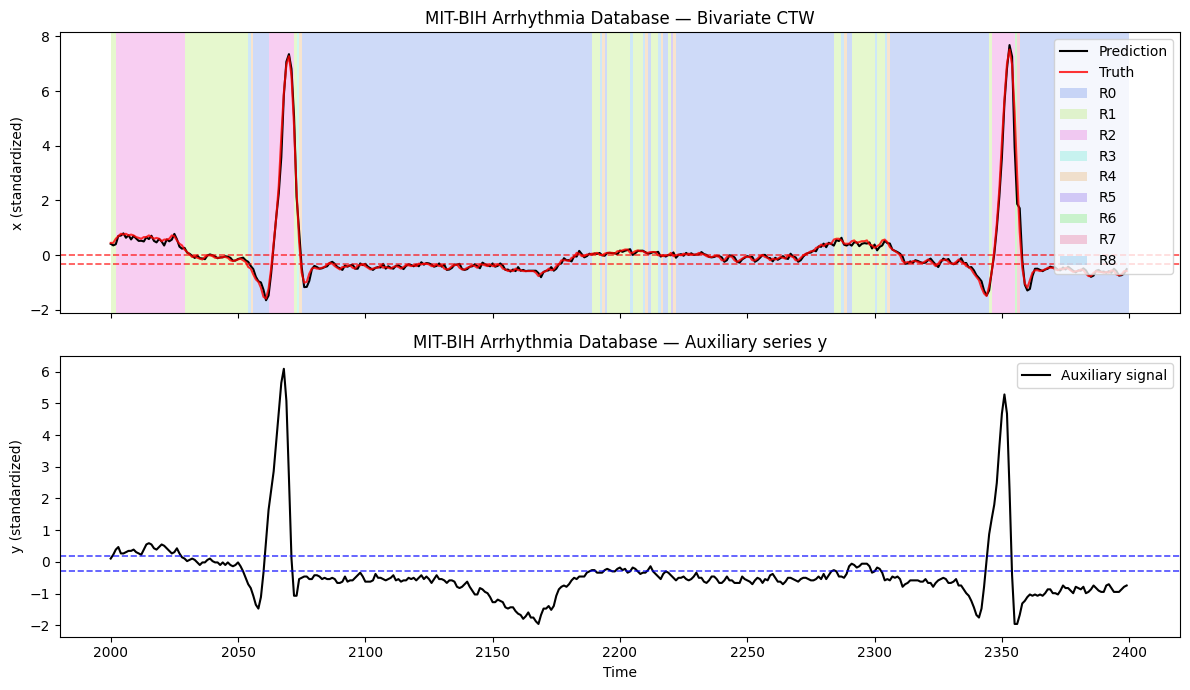

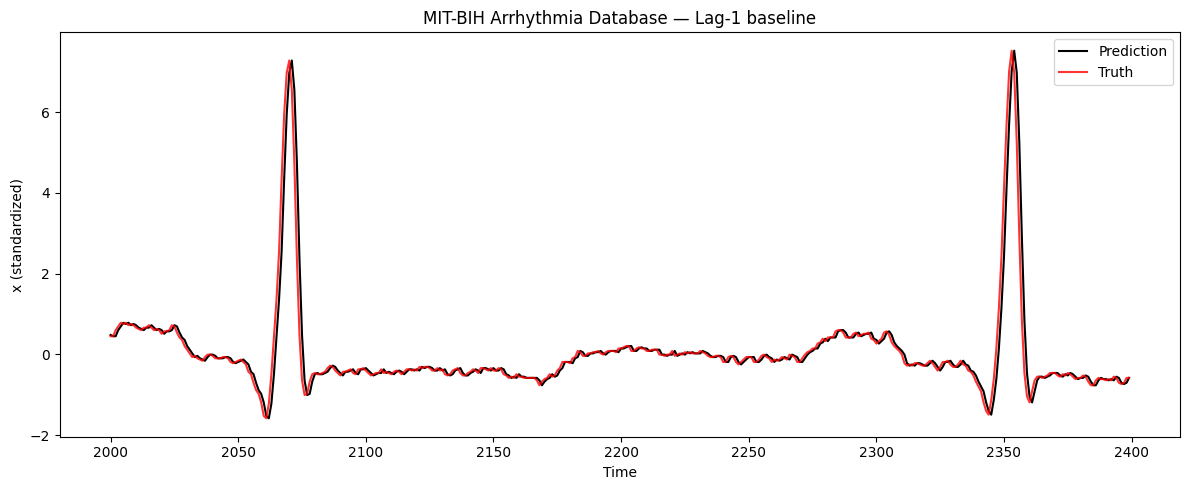

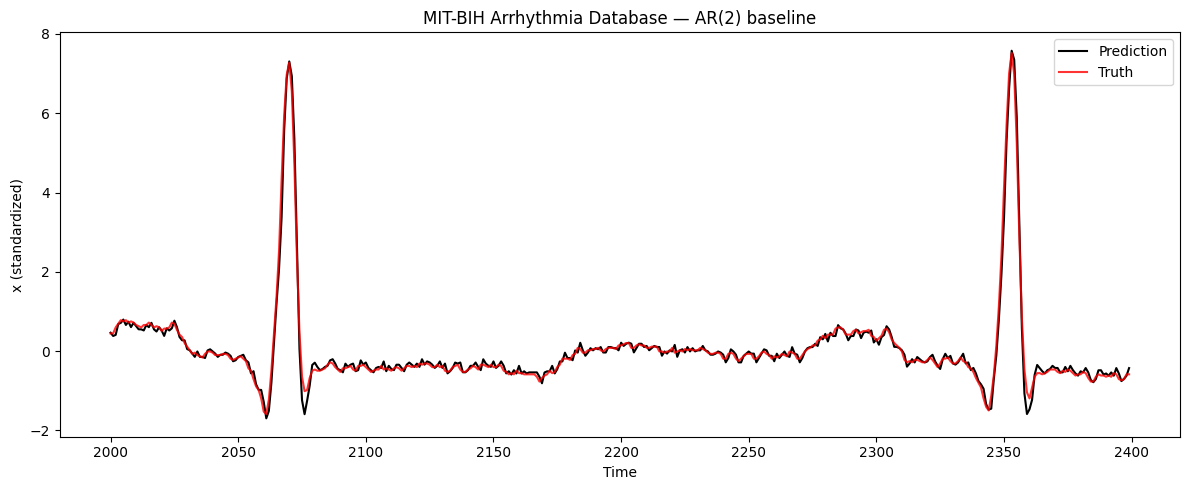

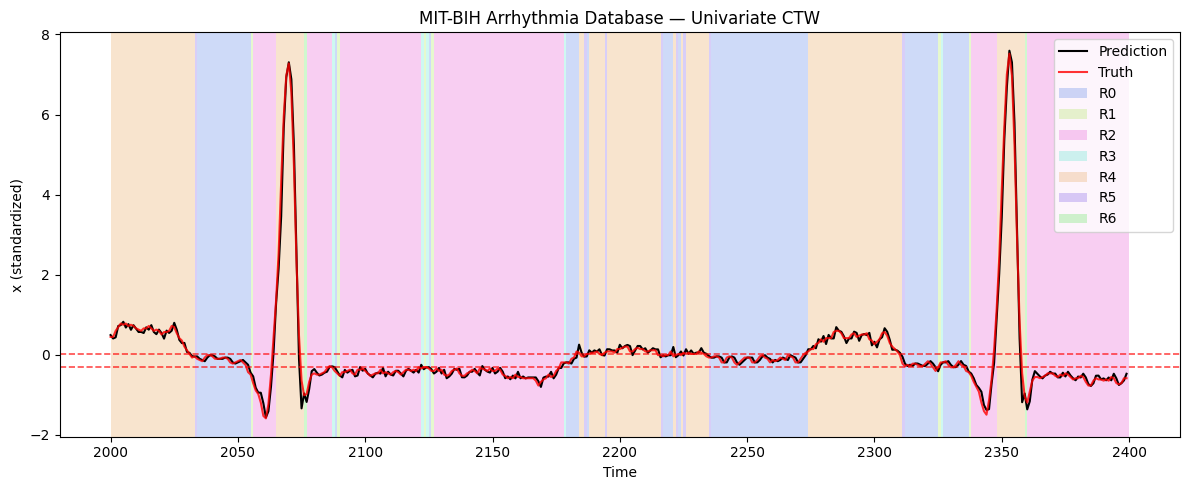

Benchmark terminé


,mse_1step,mae_1step,mse_k3,mae_k3,mse_k5,mae_k5,mse_k10,mae_k10
lag1,0.100979,0.119317,0.377749,0.181093,0.856994,0.249120,2.550021,0.526466
ar,0.019845,0.091185,0.203529,0.212854,0.170700,0.255355,0.993591,0.496837
univariate,0.016130,0.080814,0.071297,0.150500,0.094927,0.167314,0.443434,0.286113
bivariate,0.013225,0.076441,0.040490,0.129310,0.195943,0.193177,2.521931,0.469416


In [2]:
print(list_datasets())

ds, out = run_dataset_benchmark(
    "mitbih",
    n_samples=8000,
    make_plots=True,
    n_samples_plot=400,
    use_future_y_bivariate=False,
    plot_trees=True,
    order_uni=2,
    max_depth_uni=2,
    beta_uni=0.5,
    order_bi=2,
    max_depth_bi=2,
    beta_bi=0.9,
    quantizer_seq_bi=[1, 1, 1, 1],
    aux_source = "y"
)
pd.DataFrame(out["scores"]).T

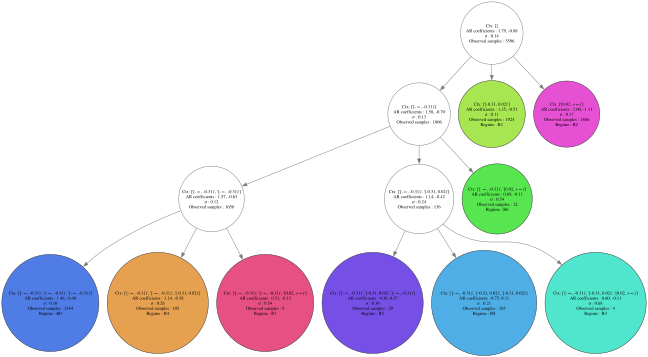

In [3]:
view_tree(
    out["bi_tree"].tree,
    quantizer=out["uni_q"],
    quantizer_seq=out["bi_thresholds"].get("quantizer_seq"),
    context_map=out["plot_artifacts"]["bivariate"]["context_map"],
)

[BIDMC-PPG] Chargement sujet 01…
Début du benchmark
[DATA] Train=5600 | Test=2400
[lag1] Évaluation 1-step...
[lag1] mse_1step=0.008626 | mae_1step=0.062197
[AR] Fit sur le train uniquement...
[AR] Fitting AR(2) sur 5600 points de train...
[AR] Fit terminé. intercept=-0.0000, coefs=[ 1.96785455 -0.97952133]
[AR] mse_1step=0.000396 | mae_1step=0.015423
[Univariate CTW] Fit sur le train uniquement...
[Univariate CTW] Initialisation du modèle (order=2, max_depth=2, n_passes=4)


[Univariate CTW] Passes train:   0%|          | 0/4 [00:00<?, ?it/s]

[Univariate CTW] Observations:   0%|          | 0/5598 [00:00<?, ?it/s]

[Univariate CTW] Observations:   0%|          | 0/5598 [00:00<?, ?it/s]

[Univariate CTW] Observations:   0%|          | 0/5598 [00:00<?, ?it/s]

...

[lag1] k=3 | MSE=0.055095 | MAE=0.144255
[ar] k=3 | MSE=0.004617 | MAE=0.041857
[univariate] k=3 | MSE=0.003562 | MAE=0.036318
[bivariate] k=3 | MSE=0.005415 | MAE=0.044018
----------------------------------------------------------------------
[k-step] Évaluation horizon k=5


[Benchmark] Origines k=5:   0%|          | 0/50 [00:00<?, ?it/s]

[lag1] k=5 | MSE=0.088087 | MAE=0.198508
[ar] k=5 | MSE=0.012666 | MAE=0.071024
[univariate] k=5 | MSE=0.017541 | MAE=0.081666
[bivariate] k=5 | MSE=0.011216 | MAE=0.073404
----------------------------------------------------------------------
[k-step] Évaluation horizon k=10


[Benchmark] Origines k=10:   0%|          | 0/50 [00:00<?, ?it/s]

[lag1] k=10 | MSE=0.334491 | MAE=0.358292
[ar] k=10 | MSE=0.100049 | MAE=0.207556
[univariate] k=10 | MSE=0.088898 | MAE=0.178894
[bivariate] k=10 | MSE=0.098852 | MAE=0.189415


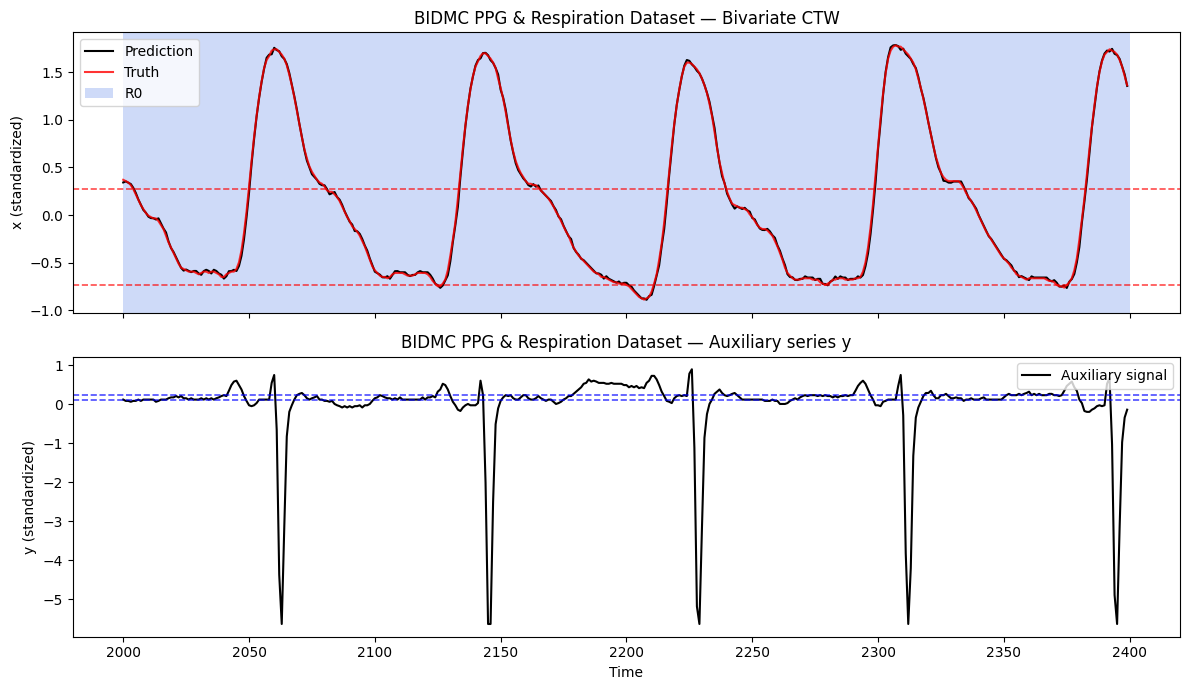

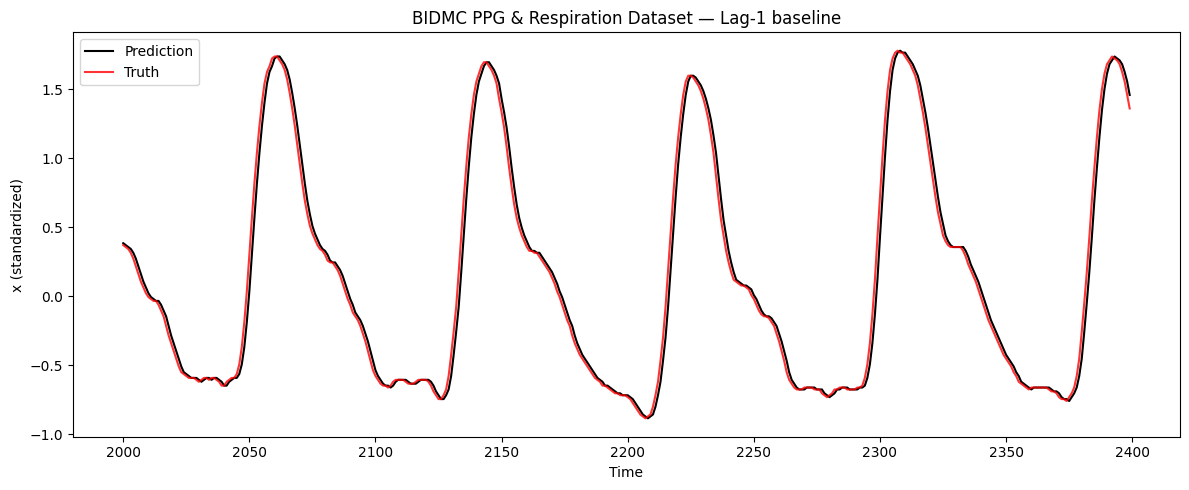

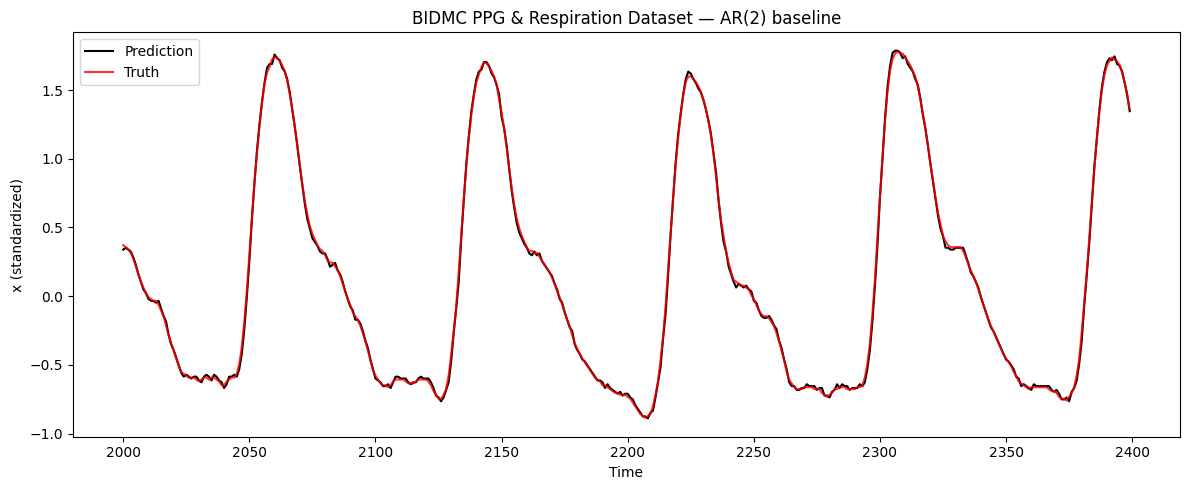

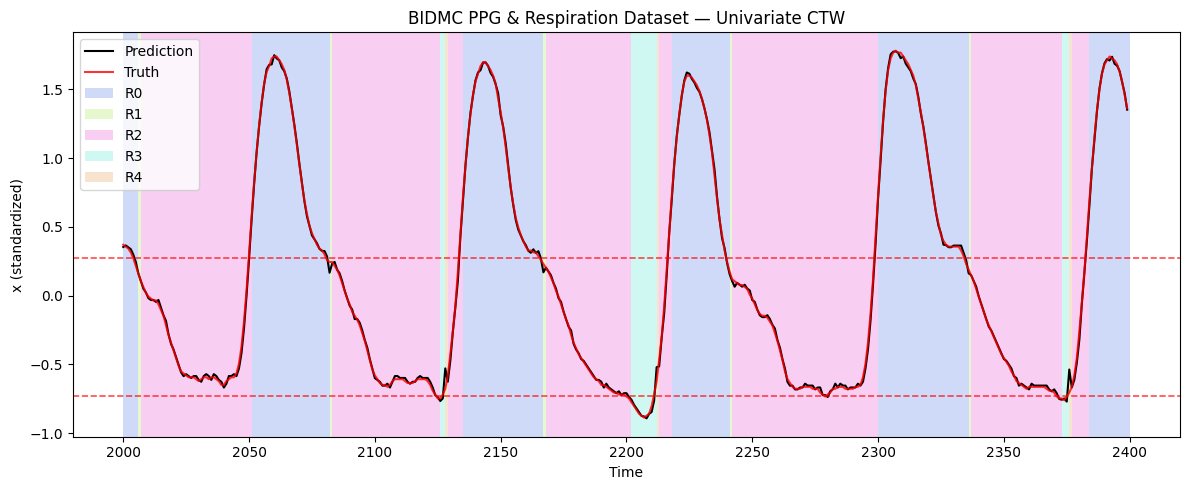

Benchmark terminé


,mse_1step,mae_1step,mse_k3,mae_k3,mse_k5,mae_k5,mse_k10,mae_k10
lag1,0.008626,0.062197,0.055095,0.144255,0.088087,0.198508,0.334491,0.358292
ar,0.000396,0.015423,0.004617,0.041857,0.012666,0.071024,0.100049,0.207556
univariate,0.000549,0.015877,0.003562,0.036318,0.017541,0.081666,0.088898,0.178894
bivariate,0.000452,0.015805,0.005415,0.044018,0.011216,0.073404,0.098852,0.189415


In [4]:
ds, out = run_dataset_benchmark("bidmc_ppg",n_samples=8000,use_future_y_bivariate=False,order_bi=2,max_depth_bi=2,quantizer_seq_bi=None,beta_bi=0.5,aux_source="y")
pd.DataFrame(out["scores"]).T

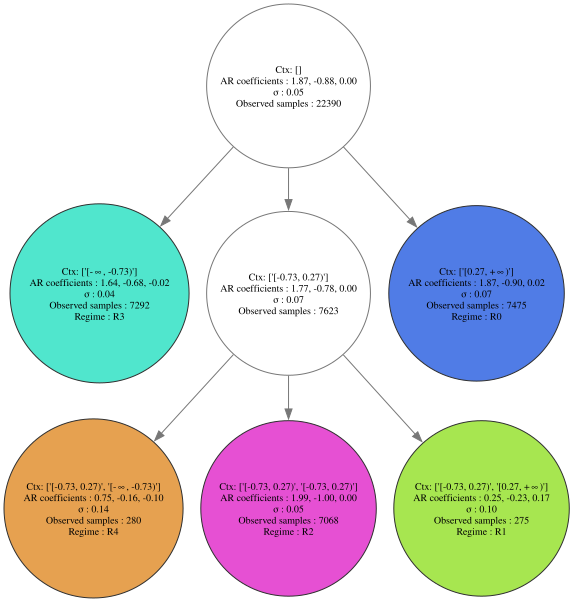

In [5]:
view_tree(
    out["uni_tree"].tree,
    quantizer=out["uni_q"],
    context_map=out["plot_artifacts"]["univariate"]["context_map"],
)


[Apnea-ECG] Chargement enregistrement a19…
Début du benchmark
[DATA] Train=14000 | Test=6000
[lag1] Évaluation 1-step...
[lag1] mse_1step=0.356286 | mae_1step=0.193859
[AR] Fit sur le train uniquement...
[AR] Fitting AR(2) sur 14000 points de train...
[AR] Fit terminé. intercept=0.0000, coefs=[ 1.34946377 -0.61260843]
[AR] mse_1step=0.181481 | mae_1step=0.152179
[Univariate CTW] Fit sur le train uniquement...
[Univariate CTW] Initialisation du modèle (order=2, max_depth=2, n_passes=4)


[Univariate CTW] Passes train:   0%|          | 0/4 [00:00<?, ?it/s]

[Univariate CTW] Observations:   0%|          | 0/13998 [00:00<?, ?it/s]

[Univariate CTW] Observations:   0%|          | 0/13998 [00:00<?, ?it/s]

[Univariate CTW] Observations:   0%|          | 0/13998 [00:00<?, ?it/s]

...

[lag1] k=3 | MSE=0.796210 | MAE=0.341450
[ar] k=3 | MSE=0.532202 | MAE=0.313157
[univariate] k=3 | MSE=0.428121 | MAE=0.226114
[bivariate] k=3 | MSE=0.612410 | MAE=0.292893
----------------------------------------------------------------------
[k-step] Évaluation horizon k=5


[Benchmark] Origines k=5:   0%|          | 0/50 [00:00<?, ?it/s]

[lag1] k=5 | MSE=0.718213 | MAE=0.246023
[ar] k=5 | MSE=0.454537 | MAE=0.281735
[univariate] k=5 | MSE=0.376210 | MAE=0.221578
[bivariate] k=5 | MSE=0.557362 | MAE=0.250039
----------------------------------------------------------------------
[k-step] Évaluation horizon k=10


[Benchmark] Origines k=10:   0%|          | 0/50 [00:00<?, ?it/s]

[lag1] k=10 | MSE=1.502869 | MAE=0.564980
[ar] k=10 | MSE=0.736959 | MAE=0.392832
[univariate] k=10 | MSE=0.635600 | MAE=0.337627
[bivariate] k=10 | MSE=0.796637 | MAE=0.361844
[Bivariate CTW] Aucun changement de y dans le test; affichage d'une fenêtre train autour d'une transition.


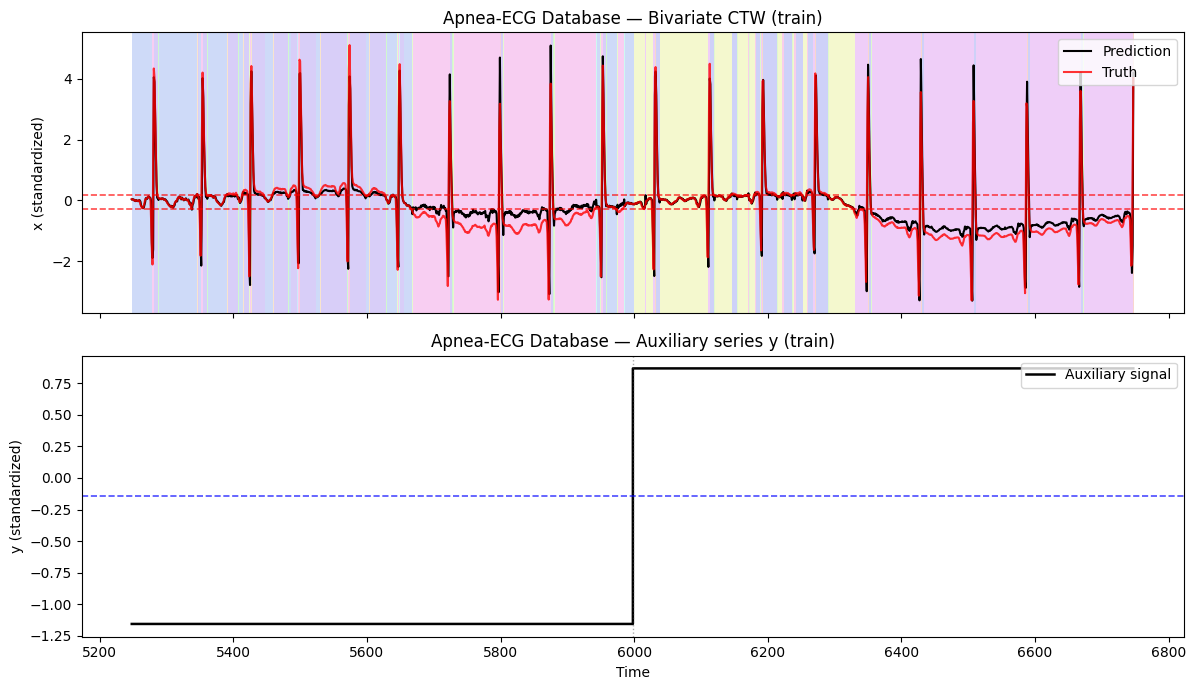

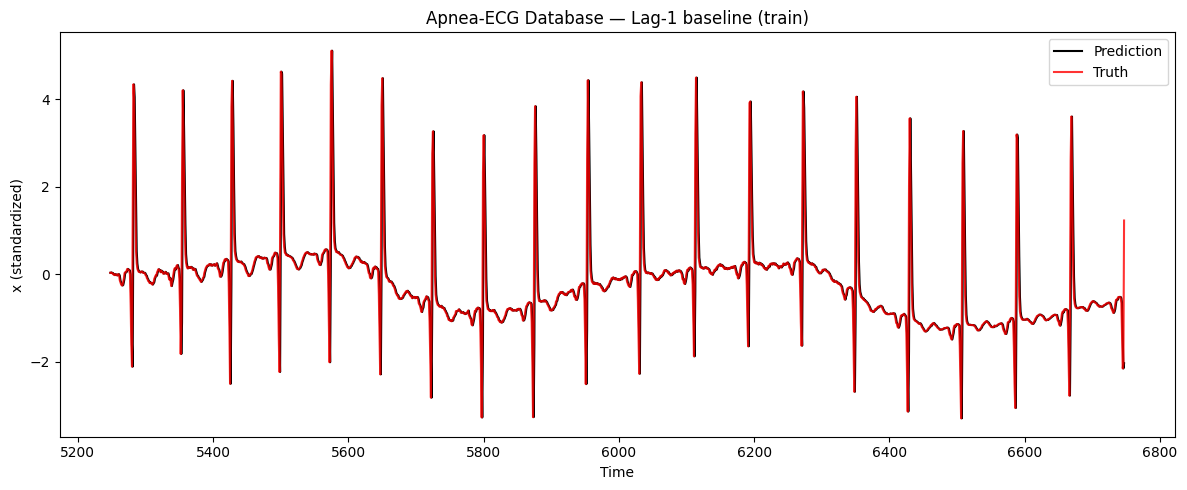

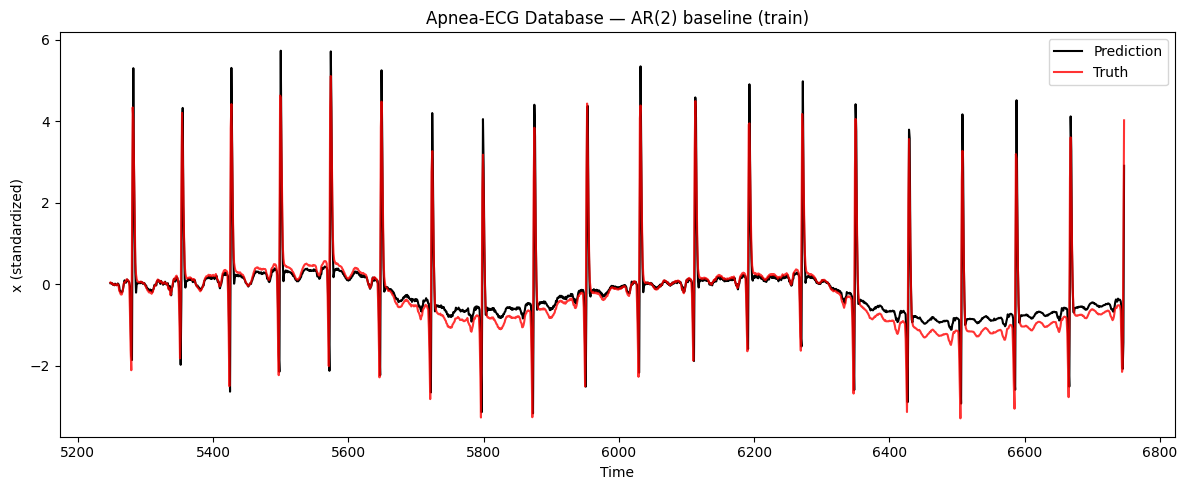

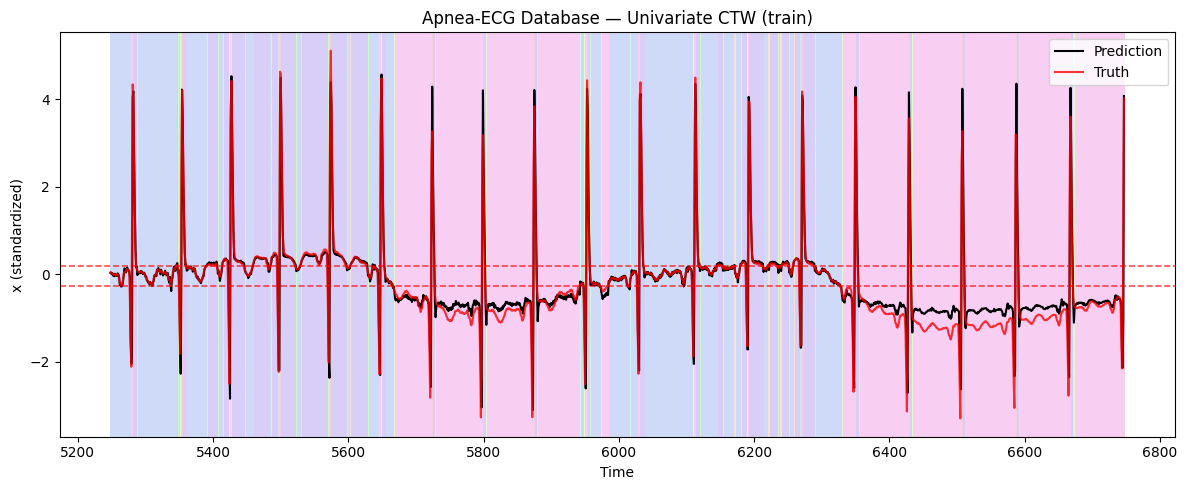

Benchmark terminé


,mse_1step,mae_1step,mse_k3,mae_k3,mse_k5,mae_k5,mse_k10,mae_k10
lag1,0.356286,0.193859,0.796210,0.341450,0.718213,0.246023,1.502869,0.564980
ar,0.181481,0.152179,0.532202,0.313157,0.454537,0.281735,0.736959,0.392832
univariate,0.108016,0.099439,0.428121,0.226114,0.376210,0.221578,0.635600,0.337627
bivariate,0.145216,0.123064,0.612410,0.292893,0.557362,0.250039,0.796637,0.361844


In [13]:
ds, out = run_dataset_benchmark(
    "apnea_ecg",
    record="a19",
    n_samples=20000,
    use_future_y_bivariate=False,
    order_uni=2,
    max_depth_uni=2,
    quantizer_seq_bi=[1,0,0],
    n_samples_plot=1500,
    plot_focus_on_aux_changes=True,
    show_regime_legend=False,
    max_depth_bi=2
)

pd.DataFrame(out["scores"]).T

In [7]:
pd.DataFrame(out["scores"]).T

,mse_1step,mae_1step,mse_k3,mae_k3,mse_k5,mae_k5,mse_k10,mae_k10
lag1,0.356286,0.193859,0.796210,0.341450,0.718213,0.246023,1.502869,0.564980
ar,0.181481,0.152179,0.532202,0.313157,0.454537,0.281735,0.736959,0.392832
univariate,0.108016,0.099439,0.428121,0.226114,0.376210,0.221578,0.635600,0.337627
bivariate,0.145216,0.123064,0.612410,0.292893,0.557362,0.250039,0.796637,0.361844


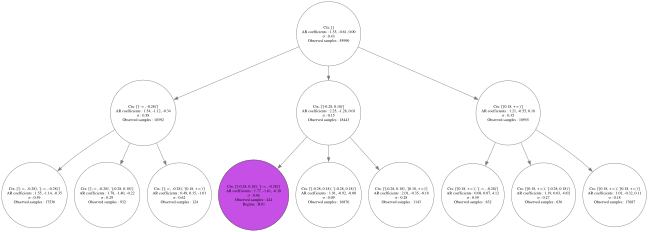

In [14]:
view_tree(
    out["uni_tree"].tree,
    quantizer=out["uni_q"],
    context_map=out["plot_artifacts"]["bivariate"]["context_map"],
)

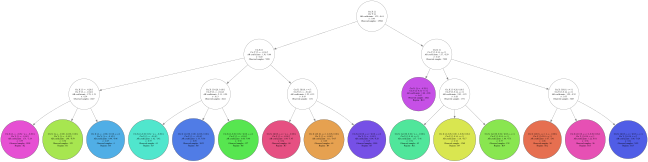

In [15]:
view_tree(
    out["bi_tree"].tree,
    quantizer=out["bi_q"],
    context_map=out["plot_artifacts"]["bivariate"]["context_map"],
)